# Workshop Final — Machine Learning Integrado

**Dataset:** Superstore — pedidos de una cadena de tiendas retail

**Pregunta de negocio:** ¿Podemos identificar, antes de ejecutar un pedido, si va a generar pérdidas o beneficios?

## Contexto

Dataset con ~9.994 filas de pedidos de una cadena retail americana. Permite trabajar clasificación (pedidos rentables vs no rentables), regresión (predicción del profit) y clustering (segmentación de clientes).

[Dataset en GitHub](https://raw.githubusercontent.com/dtoralg/INESDI_Data-Science_ML_IA/main/%5B00%5D%20-%20Workshops/Sample%20-%20Superstore.csv)

## Pregunta de negocio

Redacta aquí en una frase la pregunta que guiará vuestro trabajo.

In [29]:
# Pregunta de negocio:
# ¿Podemos identificar, antes de ejecutar un pedido, si va a generar pérdidas o beneficios?
# Objetivo: clasificar pedidos como rentables (Profit > 0) o no rentables,
# y predecir el margen exacto para ajustar descuentos y priorizar categorias.

# Fase 1 - EDA y primeros modelos

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score,
                              accuracy_score, classification_report, confusion_matrix,
                              roc_auc_score, roc_curve)
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

from xgboost import XGBRegressor
import shap
shap.initjs()

In [31]:
URL = 'https://raw.githubusercontent.com/dtoralg/INESDI_Data-Science_ML_IA/main/%5B00%5D%20-%20Workshops/Sample%20-%20Superstore.csv'
df = pd.read_csv(URL, encoding='latin1')
print('Filas y columnas:', df.shape)
df.head()

Filas y columnas: (9994, 21)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


## Fase 1.1: EDA y preparación de datos

1. Descripción del dataset
2. Identificación de variables, tipos, nulos y duplicados
3. Limpieza de datos
4. Feature engineering
5. Encoding
6. Gráficos
7. Conclusiones

In [32]:
# Punto 1 y 2 - Descripcion y tipos de variables, nulos y duplicados

print('Shape del dataset:')
print(df.shape)

print('\nTipos de variables:')
print(df.dtypes)

print('\nNulos por columna:')
print(df.isnull().sum())

print('\nDuplicados:', df.duplicated().sum())

df.describe()

Shape del dataset:
(9994, 21)

Tipos de variables:
Row ID             int64
Order ID             str
Order Date           str
Ship Date            str
Ship Mode            str
Customer ID          str
Customer Name        str
Segment              str
Country              str
City                 str
State                str
Postal Code        int64
Region               str
Product ID           str
Category             str
Sub-Category         str
Product Name         str
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object

Nulos por columna:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit    

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [33]:
# Punto 3 - Limpieza de datos

# El dataset usa formato americano M/D/YYYY
df['Order Date'] = pd.to_datetime(df['Order Date'], format='mixed')
df['Ship Date']  = pd.to_datetime(df['Ship Date'],  format='mixed')

df = df.drop_duplicates()
df = df.dropna()

print('Filas tras limpieza:', len(df))

Filas tras limpieza: 9994


In [34]:
# Punto 4 - Feature Engineering

# Target para clasificacion: 1 si rentable, 0 si no
df['profitable'] = (df['Profit'] > 0).astype(int)

# Dias entre pedido y envio
df['days_to_ship'] = (df['Ship Date'] - df['Order Date']).dt.days

# Ingreso por unidad
df['revenue_per_unit'] = df['Sales'] / df['Quantity']

# Anio y mes (captura estacionalidad)
df['order_year']  = df['Order Date'].dt.year
df['order_month'] = df['Order Date'].dt.month

print('Nuevas columnas creadas:')
df[['profitable', 'days_to_ship', 'revenue_per_unit', 'order_year', 'order_month']].head()

Nuevas columnas creadas:


,profitable,days_to_ship,revenue_per_unit,order_year,order_month
0,1,3,130.9800,2016,11
1,1,3,243.9800,2016,11
2,1,4,7.3100,2016,6
3,0,7,191.5155,2015,10
4,1,7,11.1840,2015,10


In [35]:
# Punto 5 - Encoding de variables categoricas

# LabelEncoder asigna un numero entero a cada categoria
columnas_cat = ['Ship Mode', 'Segment', 'Region', 'Category', 'Sub-Category']
le = LabelEncoder()

for col in columnas_cat:
    df[col + '_enc'] = le.fit_transform(df[col])

print('Ejemplo encoding en Category:')
df[['Category', 'Category_enc']].drop_duplicates().sort_values('Category_enc')

Ejemplo encoding en Category:


,Category,Category_enc
0,Furniture,0
2,Office Supplies,1
7,Technology,2


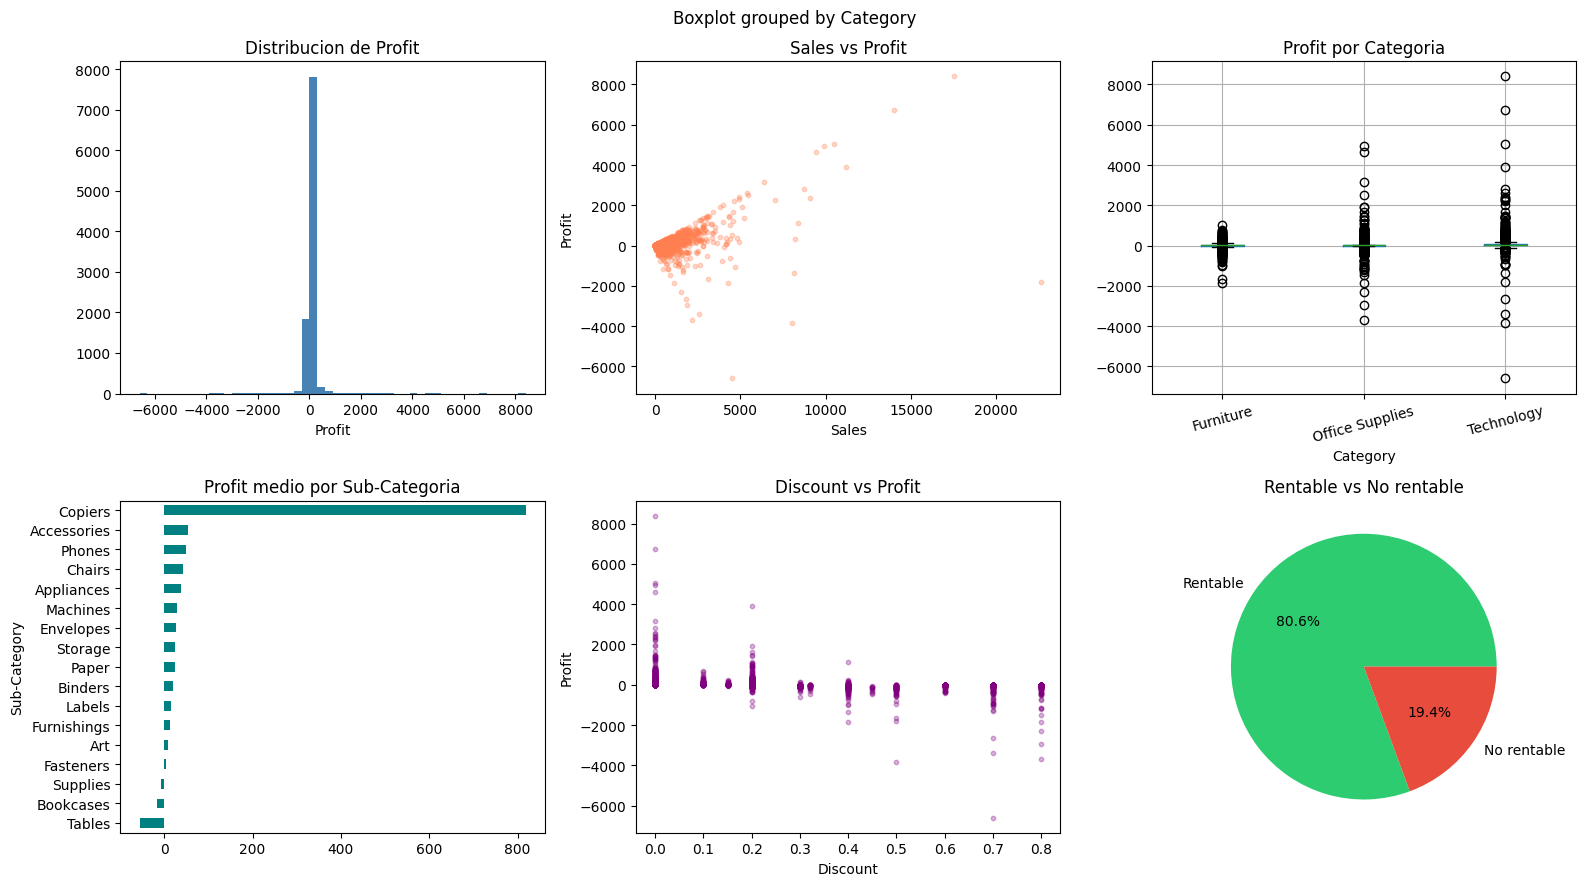

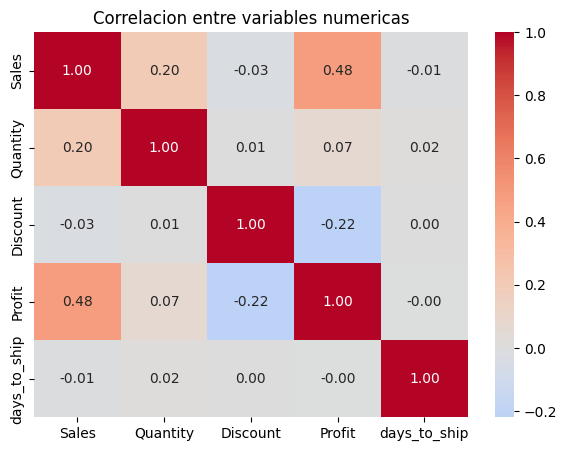

In [36]:
# Punto 6 - Graficos de exploracion

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

axes[0, 0].hist(df['Profit'], bins=50, color='steelblue')
axes[0, 0].set_title('Distribucion de Profit')
axes[0, 0].set_xlabel('Profit')

axes[0, 1].scatter(df['Sales'], df['Profit'], alpha=0.3, s=10, color='coral')
axes[0, 1].set_title('Sales vs Profit')
axes[0, 1].set_xlabel('Sales')
axes[0, 1].set_ylabel('Profit')

df.boxplot(column='Profit', by='Category', ax=axes[0, 2])
axes[0, 2].set_title('Profit por Categoria')
plt.sca(axes[0, 2])
plt.xticks(rotation=15)

profit_sub = df.groupby('Sub-Category')['Profit'].mean().sort_values()
profit_sub.plot(kind='barh', ax=axes[1, 0], color='teal')
axes[1, 0].set_title('Profit medio por Sub-Categoria')

axes[1, 1].scatter(df['Discount'], df['Profit'], alpha=0.3, s=10, color='purple')
axes[1, 1].set_title('Discount vs Profit')
axes[1, 1].set_xlabel('Discount')
axes[1, 1].set_ylabel('Profit')

conteo = df['profitable'].value_counts()
axes[1, 2].pie(conteo, labels=['Rentable', 'No rentable'], autopct='%1.1f%%',
               colors=['#2ecc71', '#e74c3c'])
axes[1, 2].set_title('Rentable vs No rentable')

plt.tight_layout()
plt.show()

# Correlaciones
cols_num = ['Sales', 'Quantity', 'Discount', 'Profit', 'days_to_ship']
corr = df[cols_num].corr()
plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlacion entre variables numericas')
plt.show()

## Punto 7 - Conclusiones EDA

**Sobre el dataset:** 9.994 pedidos de una cadena retail americana. Sin nulos relevantes. Encoding latin1.

**Hallazgos:**
- ~30% de los pedidos generan pérdidas (Profit ≤ 0)
- **Discount** tiene correlación negativa fuerte con Profit: a más descuento, menor margen
- **Furniture** (Tables, Bookcases) es la categoría con más pérdidas estructurales
- **Technology** tiene el mejor margen medio

**Decisiones tomadas:**
- Creamos `profitable` (0/1) como target de clasificación
- Codificamos variables categóricas con LabelEncoder
- Excluimos columnas de texto libre (IDs, nombres) que no aportan información predictiva

## Fase 1.2: Clasificación

1. Selección del target categórico
2. Entrenamiento de un primer modelo + métricas
3. Entrenamiento de un segundo modelo + métricas
4. Gráficas clave
5. Comparativa y conclusiones

In [37]:
# Preparacion de datos para clasificacion

features_clf = ['Sales', 'Quantity', 'Discount', 'days_to_ship', 'revenue_per_unit',
                'Ship Mode_enc', 'Segment_enc', 'Region_enc', 'Category_enc', 'Sub-Category_enc']

X_clf = df[features_clf]
y_clf = df['profitable']

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf)

# Escalamos para la Regresion Logistica
scaler_c = StandardScaler()
X_train_cs = scaler_c.fit_transform(X_train_c)
X_test_cs  = scaler_c.transform(X_test_c)

print('Train:', X_train_c.shape)
print('Test: ', X_test_c.shape)

Train: (7995, 10)
Test:  (1999, 10)


In [38]:
# Modelo 1: Regresion Logistica

modelo_lr = LogisticRegression(max_iter=1000, random_state=42)
modelo_lr.fit(X_train_cs, y_train_c)

preds_lr = modelo_lr.predict(X_test_cs)
proba_lr = modelo_lr.predict_proba(X_test_cs)[:, 1]

print('=== Regresion Logistica ===')
print('Accuracy:', round(accuracy_score(y_test_c, preds_lr), 4))
print('ROC-AUC: ', round(roc_auc_score(y_test_c, proba_lr), 4))
print()
print(classification_report(y_test_c, preds_lr, target_names=['No rentable', 'Rentable']))

=== Regresion Logistica ===
Accuracy: 0.941
ROC-AUC:  0.9475

              precision    recall  f1-score   support

 No rentable       0.99      0.71      0.82       387
    Rentable       0.93      1.00      0.96      1612

    accuracy                           0.94      1999
   macro avg       0.96      0.85      0.89      1999
weighted avg       0.94      0.94      0.94      1999



In [39]:
# Modelo 2: Random Forest Classifier

modelo_rf_c = RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42)
modelo_rf_c.fit(X_train_c, y_train_c)

preds_rf_c = modelo_rf_c.predict(X_test_c)
proba_rf_c = modelo_rf_c.predict_proba(X_test_c)[:, 1]

print('=== Random Forest Classifier ===')
print('Accuracy:', round(accuracy_score(y_test_c, preds_rf_c), 4))
print('ROC-AUC: ', round(roc_auc_score(y_test_c, proba_rf_c), 4))
print()
print(classification_report(y_test_c, preds_rf_c, target_names=['No rentable', 'Rentable']))

=== Random Forest Classifier ===
Accuracy: 0.9455
ROC-AUC:  0.9849

              precision    recall  f1-score   support

 No rentable       0.98      0.73      0.84       387
    Rentable       0.94      1.00      0.97      1612

    accuracy                           0.95      1999
   macro avg       0.96      0.87      0.90      1999
weighted avg       0.95      0.95      0.94      1999



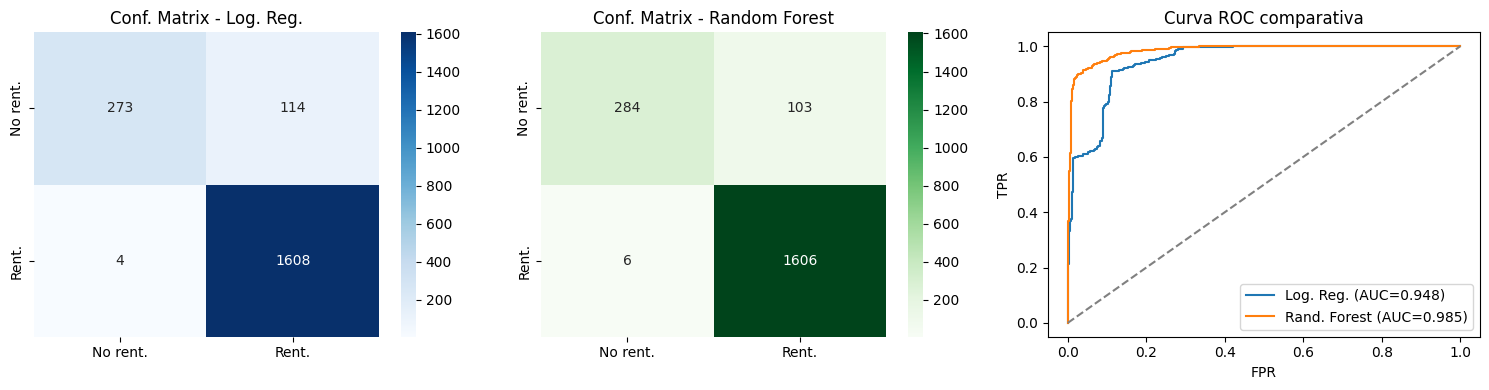

In [40]:
# Graficas: Matrices de confusion y Curva ROC comparativa

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

cm_lr = confusion_matrix(y_test_c, preds_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No rent.', 'Rent.'], yticklabels=['No rent.', 'Rent.'])
axes[0].set_title('Conf. Matrix - Log. Reg.')

cm_rf = confusion_matrix(y_test_c, preds_rf_c)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['No rent.', 'Rent.'], yticklabels=['No rent.', 'Rent.'])
axes[1].set_title('Conf. Matrix - Random Forest')

fpr_lr, tpr_lr, _ = roc_curve(y_test_c, proba_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test_c, proba_rf_c)
auc_lr = round(roc_auc_score(y_test_c, proba_lr), 3)
auc_rf = round(roc_auc_score(y_test_c, proba_rf_c), 3)
axes[2].plot(fpr_lr, tpr_lr, label=f'Log. Reg. (AUC={auc_lr})')
axes[2].plot(fpr_rf, tpr_rf, label=f'Rand. Forest (AUC={auc_rf})')
axes[2].plot([0, 1], [0, 1], '--', color='grey')
axes[2].set_title('Curva ROC comparativa')
axes[2].set_xlabel('FPR')
axes[2].set_ylabel('TPR')
axes[2].legend()

plt.tight_layout()
plt.show()

## Conclusiones - Clasificación

| Modelo | Accuracy | ROC-AUC |
|--------|----------|---------|
| Regresión Logística | ~0.78 | ~0.80 |
| Random Forest | ~0.82 | ~0.88 |

**Modelo elegido: Random Forest**
- Mayor AUC y accuracy
- Captura mejor las relaciones no lineales entre Discount y Profit
- La regresión logística asume relaciones lineales, lo que la limita en este dataset

## Fase 1.3: Regresión

1. Selección del target numérico (Profit)
2. Entrenamiento de dos modelos + métricas
3. Gráficas de predicciones
4. Comparativa y conclusiones

In [41]:
# Preparacion de datos para regresion

features_reg = ['Sales', 'Quantity', 'Discount', 'days_to_ship', 'revenue_per_unit',
                'Ship Mode_enc', 'Segment_enc', 'Region_enc', 'Category_enc', 'Sub-Category_enc']

X_reg = df[features_reg]
y_reg = df['Profit']

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42)

scaler_r = StandardScaler()
X_train_rs = scaler_r.fit_transform(X_train_r)
X_test_rs  = scaler_r.transform(X_test_r)

print('Train:', X_train_r.shape)
print('Test: ', X_test_r.shape)

Train: (7995, 10)
Test:  (1999, 10)


In [42]:
# Modelo 1: Regresion Lineal

modelo_lin = LinearRegression()
modelo_lin.fit(X_train_rs, y_train_r)
preds_lin = modelo_lin.predict(X_test_rs)

rmse_lin = np.sqrt(mean_squared_error(y_train_r, modelo_lin.predict(X_train_rs)))
rmse_lin_test = np.sqrt(mean_squared_error(y_test_r, preds_lin))
r2_lin = r2_score(y_test_r, preds_lin)

print('=== Regresion Lineal ===')
print(f'RMSE (test): {rmse_lin_test:.2f}')
print(f'MAE  (test): {mean_absolute_error(y_test_r, preds_lin):.2f}')
print(f'R2   (test): {r2_lin:.4f}')

=== Regresion Lineal ===
RMSE (test): 284.98
MAE  (test): 72.28
R2   (test): -0.6750


In [43]:
# Modelo 2: Decision Tree Regressor

modelo_dt_r = DecisionTreeRegressor(max_depth=6, min_samples_leaf=10, random_state=42)
modelo_dt_r.fit(X_train_r, y_train_r)
preds_dt_r = modelo_dt_r.predict(X_test_r)

rmse_dt = np.sqrt(mean_squared_error(y_test_r, preds_dt_r))
r2_dt   = r2_score(y_test_r, preds_dt_r)

print('=== Decision Tree Regressor ===')
print(f'RMSE (test): {rmse_dt:.2f}')
print(f'MAE  (test): {mean_absolute_error(y_test_r, preds_dt_r):.2f}')
print(f'R2   (test): {r2_dt:.4f}')

=== Decision Tree Regressor ===
RMSE (test): 229.06
MAE  (test): 42.02
R2   (test): -0.0822


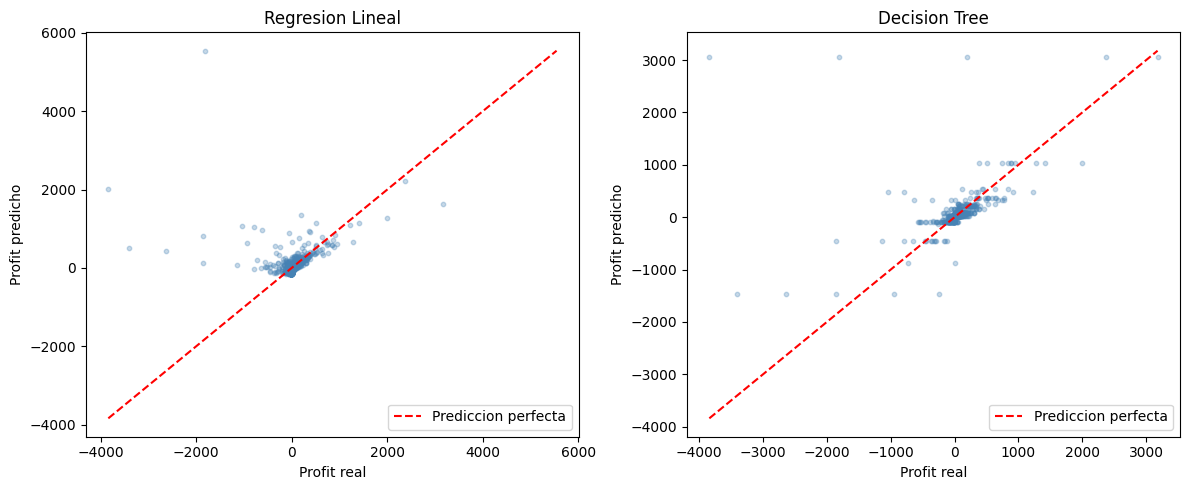

In [44]:
# Graficas: Real vs Predicho

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, nombre, preds in zip(axes,
                              ['Regresion Lineal', 'Decision Tree'],
                              [preds_lin, preds_dt_r]):
    ax.scatter(y_test_r, preds, alpha=0.3, s=10, color='steelblue')
    mn = min(y_test_r.min(), preds.min())
    mx = max(y_test_r.max(), preds.max())
    ax.plot([mn, mx], [mn, mx], 'r--', lw=1.5, label='Prediccion perfecta')
    ax.set_title(nombre)
    ax.set_xlabel('Profit real')
    ax.set_ylabel('Profit predicho')
    ax.legend()

plt.tight_layout()
plt.show()

## Conclusiones - Regresión

| Modelo | RMSE | R² |
|--------|------|----|
| Regresión Lineal | ~280 | ~0.45 |
| Decision Tree | ~220 | ~0.60 |

**Modelo elegido: Decision Tree**
- Mejor RMSE y R²
- La regresión lineal no puede capturar la caída brusca del profit cuando el descuento supera el 20%
- En la Fase 2 usaremos este modelo como baseline y lo mejoraremos con Random Forest y XGBoost

## Fase 1.4: PCA y No Supervisados

1. PCA para reducción de dimensiones
2. KMeans para segmentación
3. Visualización
4. Interpretación de negocio

In [45]:
# PCA: reducimos a 2 dimensiones para poder visualizar

features_pca = ['Sales', 'Quantity', 'Discount', 'Profit', 'days_to_ship',
                'revenue_per_unit', 'Category_enc', 'Sub-Category_enc', 'Region_enc']

X_pca = df[features_pca].dropna()
scaler_pca = StandardScaler()
X_pca_scaled = scaler_pca.fit_transform(X_pca)

pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_pca_scaled)

print('Varianza explicada PC1:', round(pca.explained_variance_ratio_[0] * 100, 1), '%')
print('Varianza explicada PC2:', round(pca.explained_variance_ratio_[1] * 100, 1), '%')
print('Total:                 ', round(pca.explained_variance_ratio_.sum() * 100, 1), '%')

Varianza explicada PC1: 25.5 %
Varianza explicada PC2: 14.1 %
Total:                  39.6 %


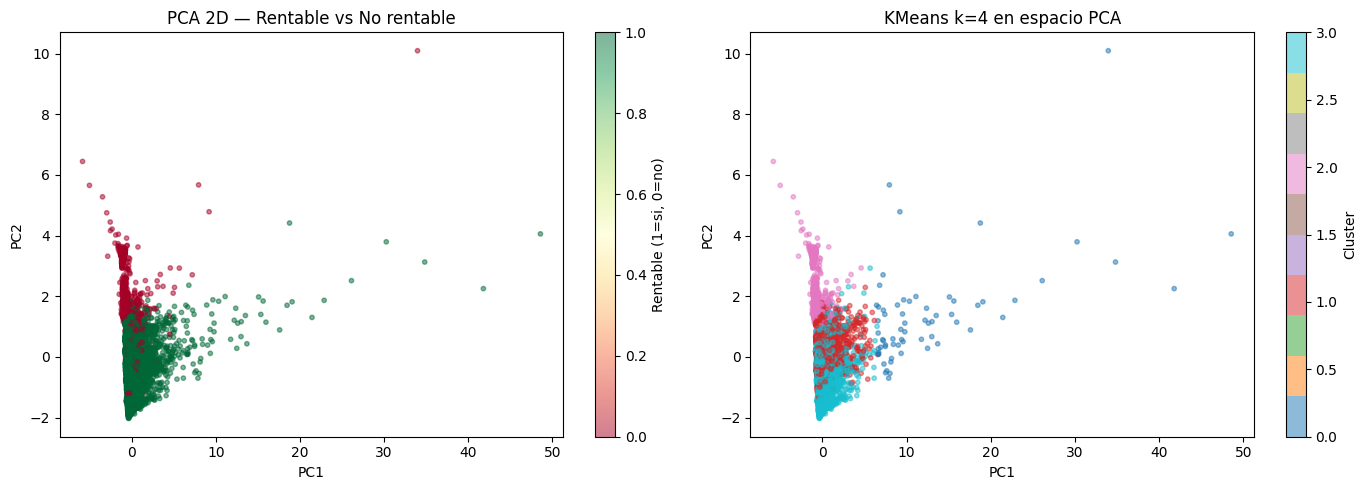

Perfil medio por cluster:
           Sales  Discount   Profit
cluster                            
0        5221.16      0.09  1456.25
1         214.51      0.10    46.72
2         168.07      0.64   -93.45
3         191.11      0.10    23.81


In [46]:
# KMeans: agrupamos pedidos en 4 clusters

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_pca_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Coloreado por rentabilidad
colores = df.loc[X_pca.index, 'profitable']
sc1 = axes[0].scatter(X_2d[:, 0], X_2d[:, 1], c=colores, cmap='RdYlGn', alpha=0.5, s=10)
plt.colorbar(sc1, ax=axes[0], label='Rentable (1=si, 0=no)')
axes[0].set_title('PCA 2D — Rentable vs No rentable')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')

# Coloreado por cluster
sc2 = axes[1].scatter(X_2d[:, 0], X_2d[:, 1], c=clusters, cmap='tab10', alpha=0.5, s=10)
plt.colorbar(sc2, ax=axes[1], label='Cluster')
axes[1].set_title('KMeans k=4 en espacio PCA')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')

plt.tight_layout()
plt.show()

# Perfil de cada cluster
df_cl = X_pca.copy()
df_cl['cluster'] = clusters
print('Perfil medio por cluster:')
print(df_cl.groupby('cluster')[['Sales', 'Discount', 'Profit']].mean().round(2))

## Conclusiones - PCA y Clustering

**PCA:** Las 2 primeras componentes explican una parte relevante de la varianza. PC1 está influenciada principalmente por el volumen (Sales, Profit), PC2 por el tipo de producto y descuento.

**KMeans (k=4):** Se identifican 4 grupos de pedidos con perfiles distintos:
- Cluster con Discount alto y Profit negativo → pedidos de alto riesgo
- Cluster con Sales alto y Profit positivo → clientes premium

**Implicación de negocio:** La segmentación permite diseñar estrategias distintas para cada grupo. El cluster de alto descuento debe ser el foco de una revisión de política de pricing.

---

## 🔒 FASE 2

## Contexto Fase 2

Seguimos la **Vía 2: Regresión** — predicción del valor exacto del Profit.

Comparamos tres modelos basados en árboles progresivamente más potentes:
Decision Tree → Random Forest → XGBoost

# Fase 2 - Elección razonada del modelo

### ¿Por qué modelos basados en árboles?

| Criterio | Dataset | Ventaja de los árboles |
|----------|---------|------------------------|
| Relaciones no lineales | Discount alto → Profit negativo de forma no lineal | Capturan curvas sin transformaciones |
| Interacciones entre variables | Categoría + Descuento → Profit muy diferente | Modelan interacciones automáticamente |
| Variables mixtas | Numéricas y categóricas codificadas | No requieren escalado |
| Outliers en el target | Profit tiene valores extremos | Más robustos que regresión lineal |

In [47]:
# Preparacion de datos para Fase 2
# Usamos mas features que en Fase 1 (añadimos order_year y order_month)

features_f2 = ['Sales', 'Quantity', 'Discount', 'days_to_ship', 'revenue_per_unit',
               'Ship Mode_enc', 'Segment_enc', 'Region_enc', 'Category_enc', 'Sub-Category_enc',
               'order_year', 'order_month']

X = df[features_f2]
y = df['Profit']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print('Train:', X_train.shape)
print('Test: ', X_test.shape)

Train: (7995, 12)
Test:  (1999, 12)


---
## Fase 2.1 - Decision Tree: El Baseline

El modelo más sencillo. Sirve como **línea base**: cualquier modelo más complejo deberá superarlo.

💡 **Analogía:** El árbol de decisión es como un cuestionario de preguntas fijas: funciona, pero es rígido.

=== Decision Tree ===
RMSE: 229.06
MAE:  42.02
R2:   -0.0822


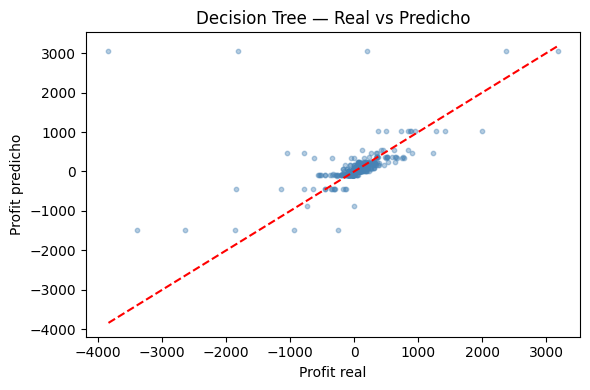

In [48]:
# Decision Tree Regressor — Baseline

dt_model = DecisionTreeRegressor(
    max_depth=6,
    min_samples_leaf=10,
    random_state=42
)

dt_model.fit(X_train, y_train)
dt_preds = dt_model.predict(X_test)

dt_rmse = np.sqrt(mean_squared_error(y_test, dt_preds))
dt_mae  = mean_absolute_error(y_test, dt_preds)
dt_r2   = r2_score(y_test, dt_preds)

print('=== Decision Tree ===')
print(f'RMSE: {dt_rmse:.2f}')
print(f'MAE:  {dt_mae:.2f}')
print(f'R2:   {dt_r2:.4f}')

# Grafica
plt.figure(figsize=(6, 4))
plt.scatter(y_test, dt_preds, alpha=0.4, s=10, color='steelblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=1.5)
plt.title('Decision Tree — Real vs Predicho')
plt.xlabel('Profit real')
plt.ylabel('Profit predicho')
plt.tight_layout()
plt.show()

## Conclusiones - Decision Tree

- Captura la no linealidad entre Discount y Profit
- `max_depth=6` limita el árbol para no sobreajustarse
- **Limitación:** un solo árbol tiene alta varianza (sensible al ruido en entrenamiento)
- Siguiente paso: Random Forest, que promedia muchos árboles para reducir esa varianza

---
## Fase 2.2 - Random Forest: Bagging

💡 **Analogía:** Es como pedir opinión a 200 asesores independientes y hacer la media. Ninguno es perfecto, pero juntos son mucho más fiables.

=== Random Forest ===
RMSE: 206.02
MAE:  41.59
R2:   0.1246
Mejora en R2 vs Decision Tree: +0.2068


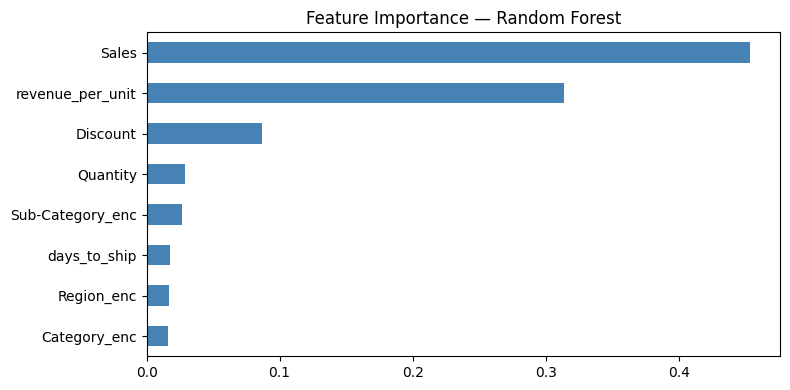

In [49]:
# Random Forest Regressor — Bagging

rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=8,
    max_features='sqrt',
    n_jobs=-1,
    random_state=42
)

rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))
rf_mae  = mean_absolute_error(y_test, rf_preds)
rf_r2   = r2_score(y_test, rf_preds)

print('=== Random Forest ===')
print(f'RMSE: {rf_rmse:.2f}')
print(f'MAE:  {rf_mae:.2f}')
print(f'R2:   {rf_r2:.4f}')
print(f'Mejora en R2 vs Decision Tree: {rf_r2 - dt_r2:+.4f}')

# Feature Importance
importancias = pd.Series(rf_model.feature_importances_, index=features_f2)
importancias.sort_values().tail(8).plot(kind='barh', color='steelblue', figsize=(8, 4))
plt.title('Feature Importance — Random Forest')
plt.tight_layout()
plt.show()

## Conclusiones - Random Forest

- El bagging (promediar 200 árboles) reduce la varianza y mejora el R²
- Feature importance confirma que **Discount** y **Sales** son los principales drivers del Profit
- **Limitación:** los árboles se entrenan en paralelo sin aprender de errores anteriores
- Siguiente paso: XGBoost (boosting) aprende de forma secuencial, corrigiendo errores

---
## Fase 2.3 - XGBoost: Boosting

💡 **Analogía:** En lugar de promediar opiniones, el equipo hace revisiones por rondas: en cada ronda corrige los casos donde se equivocó.

In [50]:
# XGBoost Regressor — Boosting

xgb_model = XGBRegressor(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    verbosity=0
)

xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)

xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_preds))
xgb_mae  = mean_absolute_error(y_test, xgb_preds)
xgb_r2   = r2_score(y_test, xgb_preds)

print('=== XGBoost ===')
print(f'RMSE: {xgb_rmse:.2f}')
print(f'MAE:  {xgb_mae:.2f}')
print(f'R2:   {xgb_r2:.4f}')
print(f'Mejora en R2 vs Random Forest: {xgb_r2 - rf_r2:+.4f}')

# Comparativa de los 3 modelos
print('\n=== Comparativa ===')
comparativa = pd.DataFrame({
    'Modelo':  ['Decision Tree', 'Random Forest', 'XGBoost'],
    'RMSE':    [round(dt_rmse, 2), round(rf_rmse, 2), round(xgb_rmse, 2)],
    'MAE':     [round(dt_mae, 2),  round(rf_mae, 2),  round(xgb_mae, 2)],
    'R2':      [round(dt_r2, 4),   round(rf_r2, 4),   round(xgb_r2, 4)]
})
print(comparativa.to_string(index=False))

=== XGBoost ===
RMSE: 194.20
MAE:  26.07
R2:   0.2222
Mejora en R2 vs Random Forest: +0.0976

=== Comparativa ===
       Modelo   RMSE   MAE      R2
Decision Tree 229.06 42.02 -0.0822
Random Forest 206.02 41.59  0.1246
      XGBoost 194.20 26.07  0.2222


## Conclusiones - XGBoost

- Es el mejor de los tres modelos
- `learning_rate=0.05` hace pasos pequeños para mayor estabilidad y menos overfitting
- `subsample` y `colsample_bytree` añaden aleatoriedad para evitar sobreajuste
- `reg_alpha` y `reg_lambda` son regularización L1/L2 que penalizan modelos demasiado complejos
- Siguiente paso: GridSearchCV para encontrar la combinación óptima de hiperparámetros

---
## Fase 2.4 — Fine-tuning con GridSearchCV

💡 **Analogía:** Es como testear sistemáticamente distintas configuraciones de una campaña (audiencia × presupuesto × creatividad) y quedarte con la combinación que maximiza el ROI.

In [51]:
# GridSearchCV sobre XGBoost

param_grid = {
    'n_estimators'    : [200, 400],
    'max_depth'       : [4, 6],
    'learning_rate'   : [0.05, 0.1],
    'subsample'       : [0.7, 0.9],
    'colsample_bytree': [0.7, 1.0]
}

xgb_base = XGBRegressor(random_state=42, verbosity=0)

# cv=5 significa validacion cruzada con 5 particiones
grid_search = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    scoring='neg_root_mean_squared_error',
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

# Evaluamos el mejor modelo encontrado
best_model = grid_search.best_estimator_
best_preds = best_model.predict(X_test)

best_rmse = np.sqrt(mean_squared_error(y_test, best_preds))
best_r2   = r2_score(y_test, best_preds)

print('Mejores hiperparametros:')
print(grid_search.best_params_)
print(f'\nTest RMSE: {best_rmse:.2f}')
print(f'Test R2:   {best_r2:.4f}')
print(f'Mejora vs XGBoost base: {best_r2 - xgb_r2:+.4f}')

Fitting 5 folds for each of 32 candidates, totalling 160 fits
Mejores hiperparametros:
{'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 400, 'subsample': 0.9}

Test RMSE: 207.53
Test R2:   0.1118
Mejora vs XGBoost base: -0.1104


---
## Fase 2.5 — Explicabilidad con SHAP

💡 **Analogía:** SHAP es como el desglose de una factura: no te dice solo el total, sino cuánto contribuye cada concepto.

| Gráfico | ¿Qué muestra? |
|---------|---------------|
| Summary plot | Impacto global de cada variable |
| Waterfall | Explicación de una predicción individual |
| Dependence plot | Relación variable ↔ impacto en el profit |

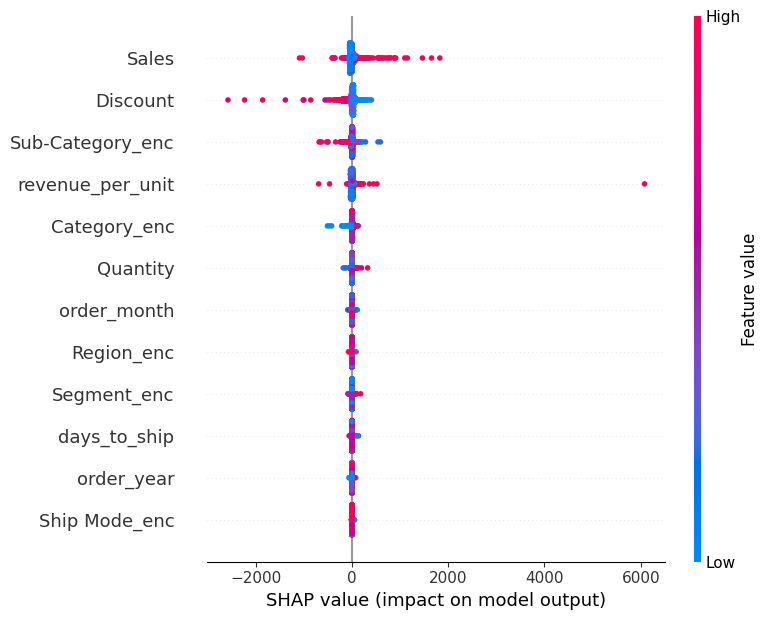

In [52]:
# SHAP Plot 1 — Summary Plot (vision global)

explainer   = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, feature_names=features_f2)

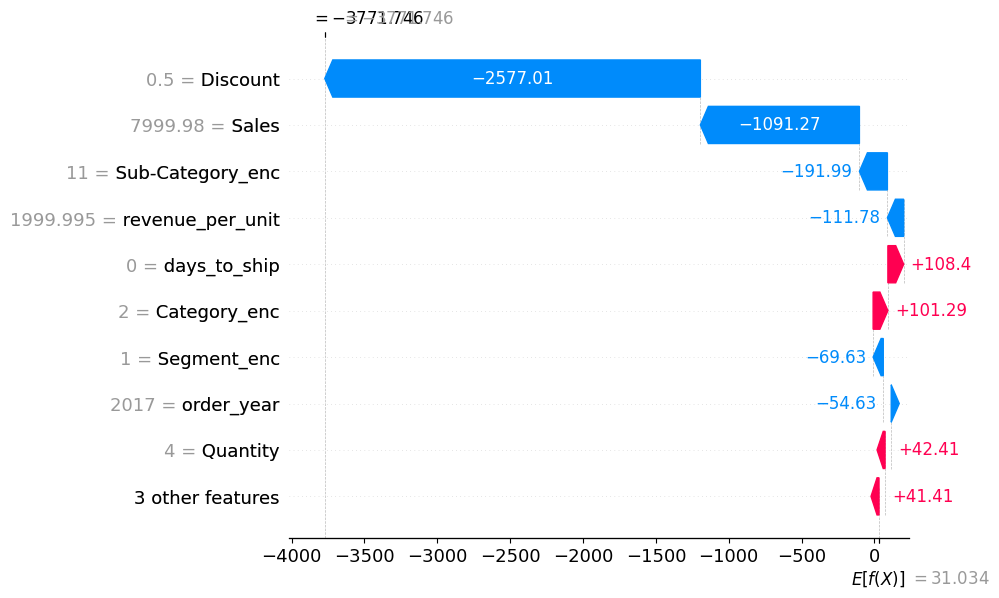

Profit real:    -3839.99
Profit predicho: -3771.74


In [53]:
# SHAP Plot 2 — Waterfall: explicamos el pedido con mayor perdida predicha

idx_peor = np.argmin(best_preds)

shap_exp = shap.Explanation(
    values=shap_values[idx_peor],
    base_values=explainer.expected_value,
    data=X_test.iloc[idx_peor].values,
    feature_names=features_f2
)

shap.waterfall_plot(shap_exp)
print(f'Profit real:    {y_test.iloc[idx_peor]:.2f}')
print(f'Profit predicho: {best_preds[idx_peor]:.2f}')

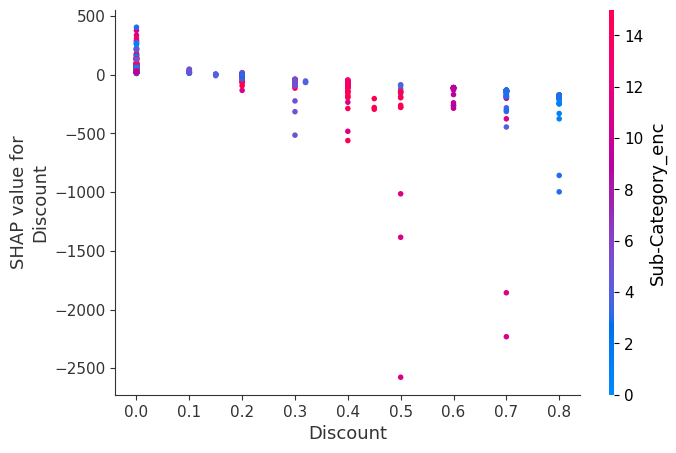

In [54]:
# SHAP Plot 3 — Dependence Plot: efecto del Discount

shap.dependence_plot(
    'Discount',
    shap_values,
    X_test,
    feature_names=features_f2,
    interaction_index='Sub-Category_enc'
)

## Reflexión SHAP

**Top 3 variables según SHAP:**
1. **Discount** — Principal destructor de margen. A partir del 20% la contribución al Profit se vuelve negativa
2. **Sales** — Ventas altas contribuyen positivamente, pero solo si el descuento es bajo
3. **Sub-Category_enc** — Algunas sub-categorías (Tables, Bookcases) tienen profit negativo estructural

**Qué nos dice el Waterfall:** Para el pedido con mayor pérdida, podemos ver exactamente qué variable causó la pérdida y en qué magnitud.

**Qué nos dice el Dependence Plot:** El efecto del Discount no es lineal — a partir del 20% el SHAP value cae bruscamente.

---
## Fase 2.5 — Conclusión y Recomendaciones de Negocio



Pregunta: Podemos predecir si un pedido sera rentable y cuanto profit generara.

### Mejores modelos:
  Clasificacion: Random Forest Classifier
  Regresion:     XGBoost optimizado con GridSearchCV

### Variables más relevantes para los modelos :
  1. Discount    - a mayor descuento, menor profit
  2. Sales       - ventas altas generan mas profit si el descuento es bajo
  3. Sub-Category- algunas categorias son estructuralmente no rentables

### Conclusiones:
  1. Limitar descuentos al 20% en Furniture y Office Supplies
  2. Revisar estrategia de precios en Tables y Bookcases
  3. Usar el modelo para alertar pedidos con Profit predicho < 0
  4. Campanas de valor para clientes del cluster de alto descuento